In [1]:
import pandas as pd
import numpy as np
import glob

In [2]:
glob.glob("*",recursive=True,include_hidden=True)

['._IDEAM_Temperatura.csv',
 'DataAllMining_Original.csv',
 'TEMP_ano_depto',
 '.ipynb_checkpoints',
 'IDEAM_Temperatura.csv',
 'RAIN_por_primeros15dias_ano_depto',
 '._IDEAM_Humedad_del_Aire_2_metros.csv',
 'AllData.zip',
 'ExtractingDataAll.ipynb',
 'IDEAM_Precipitacion.csv',
 'ManagingDataAll.ipynb',
 'DataAllMining_Imputed.csv',
 'HUMI_ano_depto',
 'RAIN_por_mes_ano_depto',
 'TEMP_por_primeros15dias_ano_depto',
 '._IDEAM_Precipitacion.csv',
 'IDEAM_Humedad_del_Aire_2_metros.csv',
 'artifacts',
 'HUMI_por_mes_ano_depto',
 'RAIN_ano_depto',
 'TEMP_por_mes_ano_depto',
 'HUMI_por_primeros15dias_ano_depto']

In [3]:
humi_days1=pd.read_csv("HUMI_ano_depto/part-00000-bdc60df3-8da0-46dd-9824-22ef67002867-c000.csv")
humi_days2=pd.read_csv("HUMI_ano_depto/part-00000-bdc60df3-8da0-46dd-9824-22ef67002867-c000.csv")
humi_days1=humi_days1[(humi_days1["Departamento"]!="<nil>")]
humi_days2=humi_days2[(humi_days2["Departamento"]!="<nil>")]

In [4]:
rain_days=pd.read_csv("RAIN_ano_depto/part-00000-a35e720f-5cbd-4d78-bcc5-f7d5d4bd93de-c000.csv")
rain_days=rain_days[(rain_days["Departamento"]!="<nil>")]

In [5]:
temp_days1=pd.read_csv("TEMP_ano_depto/part-00000-e85da6e9-33ac-4c86-87f3-476cd7d27236-c000.csv")
temp_days2=pd.read_csv("TEMP_ano_depto/part-00001-e85da6e9-33ac-4c86-87f3-476cd7d27236-c000.csv")
temp_days1=temp_days1[(temp_days1["Departamento"]!="<nil>")]
temp_days2=temp_days2[(temp_days2["Departamento"]!="<nil>")]

In [6]:
temp_days=pd.concat([temp_days1,temp_days2])
humi_days=pd.concat([humi_days1,humi_days2])
temp_days["date"]=pd.to_datetime(temp_days["date"])
rain_days["date"]=pd.to_datetime(rain_days["date"])
humi_days["date"]=pd.to_datetime(humi_days["date"])

In [7]:
temp_days

,Departamento,date,sum_ValorObservado
325,AMAZONAS,2007-05-18,20.250000
326,AMAZONAS,2007-05-19,19.209091
327,AMAZONAS,2007-05-26,19.575000
328,AMAZONAS,2007-05-27,18.837500
329,AMAZONAS,2007-05-28,19.820000
...,...,...,...
131207,VICHADA,2024-11-03,26.070833
131208,VICHADA,2024-11-04,25.579167
131209,VICHADA,2024-11-05,27.179167
131210,VICHADA,2024-11-06,28.825000


In [8]:
rain_days

,Departamento,date,sum_ValorObservado
1871,AMAZONAS,2017-01-20,1.40
1872,AMAZONAS,2017-02-02,0.30
1873,AMAZONAS,2017-02-16,10.88
1874,AMAZONAS,2017-02-17,3.21
1875,AMAZONAS,2017-02-18,0.72
...,...,...,...
151009,VICHADA,2024-11-03,15.20
151010,VICHADA,2024-11-04,34.20
151011,VICHADA,2024-11-05,0.00
151012,VICHADA,2024-11-06,0.00


In [9]:
humi_days

,Departamento,date,sum_ValorObservado
331,AMAZONAS,2007-05-18,58.625000
332,AMAZONAS,2007-05-19,58.090909
333,AMAZONAS,2007-05-26,59.416667
334,AMAZONAS,2007-05-27,61.041667
335,AMAZONAS,2007-05-28,59.350000
...,...,...,...
71795,CESAR,2014-09-10,69.937500
71796,CESAR,2014-09-11,73.791667
71797,CESAR,2014-09-12,75.066667
71798,CESAR,2014-09-13,70.083333


In [10]:
rain_days["date"].min()

Timestamp('2003-01-20 00:00:00')

In [11]:
len(list(rain_days["Departamento"].unique()))

33

## Bloque 1 — Preparar diarios (enero 1–24) y mensuales (todo el año)

In [12]:
import pandas as pd
import numpy as np

# Asegura datetime
for _df in [rain_days, temp_days, humi_days]:
    _df["date"] = pd.to_datetime(_df["date"])

def build_daily_jan(df, value_col="sum_ValorObservado", agg="sum"):
    """
    Devuelve: Departamento, Year, DayJan (1..24), value
    """
    x = df.copy()
    x["Year"] = x["date"].dt.year
    x["Month"] = x["date"].dt.month
    x["DayJan"] = x["date"].dt.day

    x = x[(x["Month"] == 1) & (x["DayJan"].between(1, 24))]

    if agg == "sum":
        out = (x.groupby(["Departamento", "Year", "DayJan"], as_index=False)[value_col]
                 .sum()
                 .rename(columns={value_col: "value"}))
    elif agg == "mean":
        out = (x.groupby(["Departamento", "Year", "DayJan"], as_index=False)[value_col]
                 .mean()
                 .rename(columns={value_col: "value"}))
    else:
        raise ValueError("agg must be 'sum' or 'mean'")
    return out

def build_monthly(df, value_col="sum_ValorObservado", agg="sum"):
    """
    Devuelve: Departamento, Year, Month (1..12), value_month
    """
    x = df.copy()
    x["Year"] = x["date"].dt.year
    x["Month"] = x["date"].dt.month

    if agg == "sum":
        out = (x.groupby(["Departamento", "Year", "Month"], as_index=False)[value_col]
                 .sum()
                 .rename(columns={value_col: "value_month"}))
    elif agg == "mean":
        out = (x.groupby(["Departamento", "Year", "Month"], as_index=False)[value_col]
                 .mean()
                 .rename(columns={value_col: "value_month"}))
    else:
        raise ValueError("agg must be 'sum' or 'mean'")
    return out

# Diarios de enero (1..24)
rain_jan = build_daily_jan(rain_days, agg="sum").rename(columns={"value": "Rain_day"})
temp_jan = build_daily_jan(temp_days, agg="mean").rename(columns={"value": "Temp_day"})
humi_jan = build_daily_jan(humi_days, agg="mean").rename(columns={"value": "Humi_day"})

# Mensuales (todo el año)
rain_m = build_monthly(rain_days, agg="sum").rename(columns={"value_month": "Rain_month"})
temp_m = build_monthly(temp_days, agg="mean").rename(columns={"value_month": "Temp_month"})
humi_m = build_monthly(humi_days, agg="mean").rename(columns={"value_month": "Humi_month"})


## Bloque 2 — Construir dataset final con 1–12 y 13–24 (segunda vuelta)

In [13]:
# Base: todos los depto-año-mes donde haya target mensual (puedes elegir el "universo" que prefieras)
base = (rain_m.merge(temp_m, on=["Departamento","Year","Month"], how="outer")
             .merge(humi_m, on=["Departamento","Year","Month"], how="outer"))

# Mapping Cabañuelas:
#  - Primario: DayJan = Month (1..12)
#  - Secundario (13..24, invertido): DayJan = 25 - Month  (Jan=24, Feb=23, ..., Dec=13)
base["Day_primary"] = base["Month"]
base["Day_secondary"] = 25 - base["Month"]

def attach_day_predictors(base_df, jan_df, value_name, day_col):
    """
    base_df: Departamento,Year,Month + (Day_primary/Day_secondary)
    jan_df : Departamento,Year,DayJan,value_name
    day_col: "Day_primary" or "Day_secondary"
    """
    tmp = jan_df.rename(columns={"DayJan": day_col})
    out = base_df.merge(tmp[["Departamento","Year",day_col,value_name]],
                        on=["Departamento","Year",day_col], how="left")
    return out

# Adjuntar predictores primarios
df2 = base.copy()
df2 = attach_day_predictors(df2, rain_jan, "Rain_day", "Day_primary").rename(columns={"Rain_day": "Rain_day_prim"})
df2 = attach_day_predictors(df2, temp_jan, "Temp_day", "Day_primary").rename(columns={"Temp_day": "Temp_day_prim"})
df2 = attach_day_predictors(df2, humi_jan, "Humi_day", "Day_primary").rename(columns={"Humi_day": "Humi_day_prim"})

# Adjuntar predictores secundarios (13–24 invertidos)
df2 = attach_day_predictors(df2, rain_jan.rename(columns={"Rain_day":"Rain_day"}), "Rain_day", "Day_secondary").rename(columns={"Rain_day": "Rain_day_sec"})
df2 = attach_day_predictors(df2, temp_jan.rename(columns={"Temp_day":"Temp_day"}), "Temp_day", "Day_secondary").rename(columns={"Temp_day": "Temp_day_sec"})
df2 = attach_day_predictors(df2, humi_jan.rename(columns={"Humi_day":"Humi_day"}), "Humi_day", "Day_secondary").rename(columns={"Humi_day": "Humi_day_sec"})

# (Opcional) combinar ambos recorridos en un solo predictor (promedio)
df2["Rain_day_avg"] = df2[["Rain_day_prim","Rain_day_sec"]].mean(axis=1)
df2["Temp_day_avg"] = df2[["Temp_day_prim","Temp_day_sec"]].mean(axis=1)
df2["Humi_day_avg"] = df2[["Humi_day_prim","Humi_day_sec"]].mean(axis=1)

# Orden final (long-table)
df_final = df2.sort_values(["Departamento","Year","Month"]).reset_index(drop=True)

df_final.head(), df_final.shape


(  Departamento  Year  Month  Rain_month  Temp_month  Humi_month  Day_primary  \
 0     AMAZONAS  2007      5         NaN   19.658589   58.768519            5   
 1     AMAZONAS  2007      6         NaN   24.355005   79.497905            6   
 2     AMAZONAS  2007      7         NaN   26.090864   85.394018            7   
 3     AMAZONAS  2007      8         NaN   26.532797   83.156696            8   
 4     AMAZONAS  2007      9         NaN   26.434267   83.572633            9   
 
    Day_secondary  Rain_day_prim  Temp_day_prim  Humi_day_prim  Rain_day_sec  \
 0             20            NaN            NaN            NaN           NaN   
 1             19            NaN            NaN            NaN           NaN   
 2             18            NaN            NaN            NaN           NaN   
 3             17            NaN            NaN            NaN           NaN   
 4             16            NaN            NaN            NaN           NaN   
 
    Temp_day_sec  Humi_day_sec

In [14]:
df_final

,Departamento,Year,Month,Rain_month,Temp_month,Humi_month,Day_primary,Day_secondary,Rain_day_prim,Temp_day_prim,Humi_day_prim,Rain_day_sec,Temp_day_sec,Humi_day_sec,Rain_day_avg,Temp_day_avg,Humi_day_avg
0,AMAZONAS,2007,5,NaN,19.658589,58.768519,5,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AMAZONAS,2007,6,NaN,24.355005,79.497905,6,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AMAZONAS,2007,7,NaN,26.090864,85.394018,7,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AMAZONAS,2007,8,NaN,26.532797,83.156696,8,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AMAZONAS,2007,9,NaN,26.434267,83.572633,9,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7118,VICHADA,2024,7,464.9,26.193864,NaN,7,18,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN
7119,VICHADA,2024,8,309.2,26.716618,NaN,8,17,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN
7120,VICHADA,2024,9,254.6,26.788140,NaN,9,16,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN
7121,VICHADA,2024,10,294.6,27.634120,NaN,10,15,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN


In [15]:
data=df_final.copy()

In [16]:
data.isna().sum()/len(data)*100

Departamento      0.000000
Year              0.000000
Month             0.000000
Rain_month       26.997052
Temp_month        2.527025
Humi_month       65.309561
Day_primary       0.000000
Day_secondary     0.000000
Rain_day_prim    33.258459
Temp_day_prim    11.231223
Humi_day_prim    68.847396
Rain_day_sec     32.359961
Temp_day_sec      9.883476
Humi_day_sec     68.047171
Rain_day_avg     30.478731
Temp_day_avg      8.142637
Humi_day_avg     67.513688
dtype: float64

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

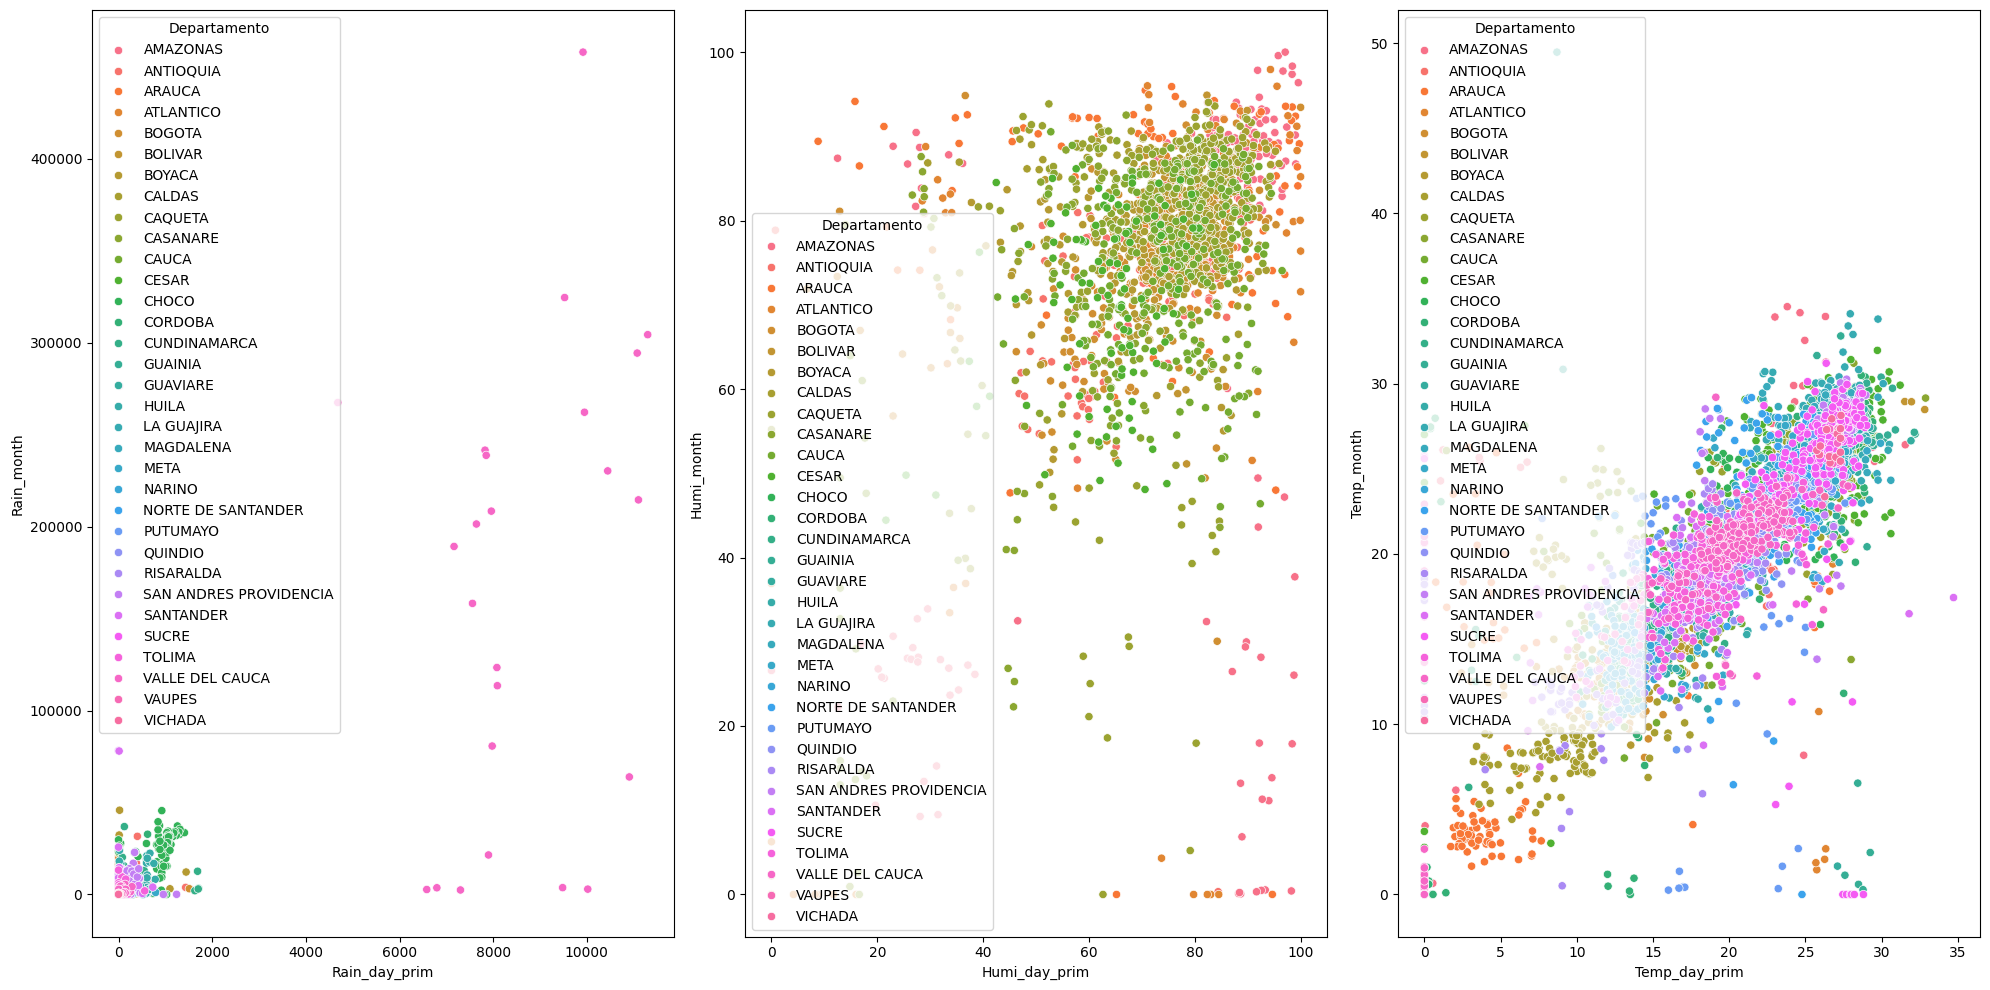

In [18]:
plt.figure(figsize=(20,10))
plt.subplot(131)
sns.scatterplot(data=data, x="Rain_day_prim", y="Rain_month",hue="Departamento")
plt.subplot(132)
sns.scatterplot(data=data, x="Humi_day_prim", y="Humi_month",hue="Departamento")
plt.subplot(133)
sns.scatterplot(data=data, x="Temp_day_prim", y="Temp_month",hue="Departamento")
plt.tight_layout();plt.show()

In [19]:
data.columns

Index(['Departamento', 'Year', 'Month', 'Rain_month', 'Temp_month',
       'Humi_month', 'Day_primary', 'Day_secondary', 'Rain_day_prim',
       'Temp_day_prim', 'Humi_day_prim', 'Rain_day_sec', 'Temp_day_sec',
       'Humi_day_sec', 'Rain_day_avg', 'Temp_day_avg', 'Humi_day_avg'],
      dtype='object')

In [20]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# ————————————————
# 0) Carga tu DataFrame (ya limpio, con columnas Year, Month/Day, Rain_day…, Departamento)
# ————————————————
# Por ejemplo, si vienes de Spark:
# df = T_spark.toPandas()

# O si ya estás en pandas:
# df = tu_dataframe_pandas.copy()

# ————————————————
# 1) Define las variables
# ————————————————
cat_feats = ['Departamento']
num_feats = ['Year', 'Month', 'Rain_month', 'Temp_month',
       'Humi_month', 'Day_primary', 'Day_secondary', 'Rain_day_prim',
       'Temp_day_prim', 'Humi_day_prim', 'Rain_day_sec', 'Temp_day_sec',
       'Humi_day_sec', 'Rain_day_avg', 'Temp_day_avg', 'Humi_day_avg']

# ————————————————
# 2) Preprocesador: one‑hot para depto, passthrough para numéricas
# ————————————————
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_feats),
    ('num', 'passthrough', num_feats),
])

# ————————————————
# 3) Iterative Imputer con bosque aleatorio
# ————————————————
rf_estimator = GradientBoostingRegressor(
    n_estimators=100,
    #n_jobs=-1,
    random_state=137
)

imputer = IterativeImputer(
    estimator=rf_estimator,
    max_iter=10,               # número de rondas de imputación
    initial_strategy='mean',   # cómo rellenar al comienzo
    imputation_order='ascending',
    random_state=137
)

pipeline = Pipeline([
    ('pre', preprocessor),
    ('imp', imputer),
])

# ————————————————
# 4) Ajusta y transforma
# ————————————————
X_imputed = pipeline.fit_transform(data)

# ————————————————
# 5) Reconstruye DataFrame con nombres de columnas
# ————————————————
# Obtén nombres de features tras el ColumnTransformer
feature_names = pipeline.named_steps['pre'].get_feature_names_out()

df_imputed = pd.DataFrame(X_imputed, columns=feature_names)

# Si quieres volver a unir columna 'Departamento' como categoría, podrías:
# departamento_cols = [c for c in feature_names if c.startswith('cat__Departamento')]
# df_imputed['Departamento'] = df_imputed[departamento_cols].idxmax(axis=1).str.replace('cat__Departamento_', '')

# ————————————————
# 6) Listo: df_imputed ya no tiene NaNs
# ————————————————
print(df_imputed.info())
print(df_imputed.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7123 entries, 0 to 7122
Data columns (total 49 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   cat__Departamento_AMAZONAS                7123 non-null   float64
 1   cat__Departamento_ANTIOQUIA               7123 non-null   float64
 2   cat__Departamento_ARAUCA                  7123 non-null   float64
 3   cat__Departamento_ATLANTICO               7123 non-null   float64
 4   cat__Departamento_BOGOTA                  7123 non-null   float64
 5   cat__Departamento_BOLIVAR                 7123 non-null   float64
 6   cat__Departamento_BOYACA                  7123 non-null   float64
 7   cat__Departamento_CALDAS                  7123 non-null   float64
 8   cat__Departamento_CAQUETA                 7123 non-null   float64
 9   cat__Departamento_CASANARE                7123 non-null   float64
 10  cat__Departamento_CAUCA             

/home/neno/.local/lib/python3.13/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [21]:
df_imputed

,cat__Departamento_AMAZONAS,cat__Departamento_ANTIOQUIA,cat__Departamento_ARAUCA,cat__Departamento_ATLANTICO,cat__Departamento_BOGOTA,cat__Departamento_BOLIVAR,cat__Departamento_BOYACA,cat__Departamento_CALDAS,cat__Departamento_CAQUETA,cat__Departamento_CASANARE,...,num__Day_secondary,num__Rain_day_prim,num__Temp_day_prim,num__Humi_day_prim,num__Rain_day_sec,num__Temp_day_sec,num__Humi_day_sec,num__Rain_day_avg,num__Temp_day_avg,num__Humi_day_avg
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,20.0,62.895832,20.833943,74.128622,17.644233,21.336949,71.061081,39.941676,21.084990,72.607614
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,19.0,26.955170,21.749081,73.859745,25.292943,21.678551,71.679886,27.136276,21.770086,72.658104
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,18.0,26.955170,21.749081,73.859745,25.292943,21.678551,71.679886,27.136276,21.770086,72.672973
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,17.0,26.955170,21.749081,73.859745,25.292943,21.678551,71.679886,27.136276,21.770086,72.672973
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,16.0,26.955170,21.749081,73.859745,25.292943,21.678551,71.679886,27.136276,21.768943,72.672973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,18.0,0.000000,21.751477,71.479631,0.000000,22.374877,72.446923,0.000000,22.013316,72.385756
7119,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,17.0,0.000000,21.764601,71.479631,0.000000,22.374877,72.446923,0.000000,22.013316,72.385756
7120,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,16.0,0.000000,21.764601,71.479631,0.000000,22.374877,72.446923,0.000000,22.013316,72.385756
7121,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,15.0,0.000000,21.764601,71.479631,0.000000,22.374877,72.446923,0.000000,22.013316,72.385756


In [22]:
df_imputed["Departamento"]=data["Departamento"]

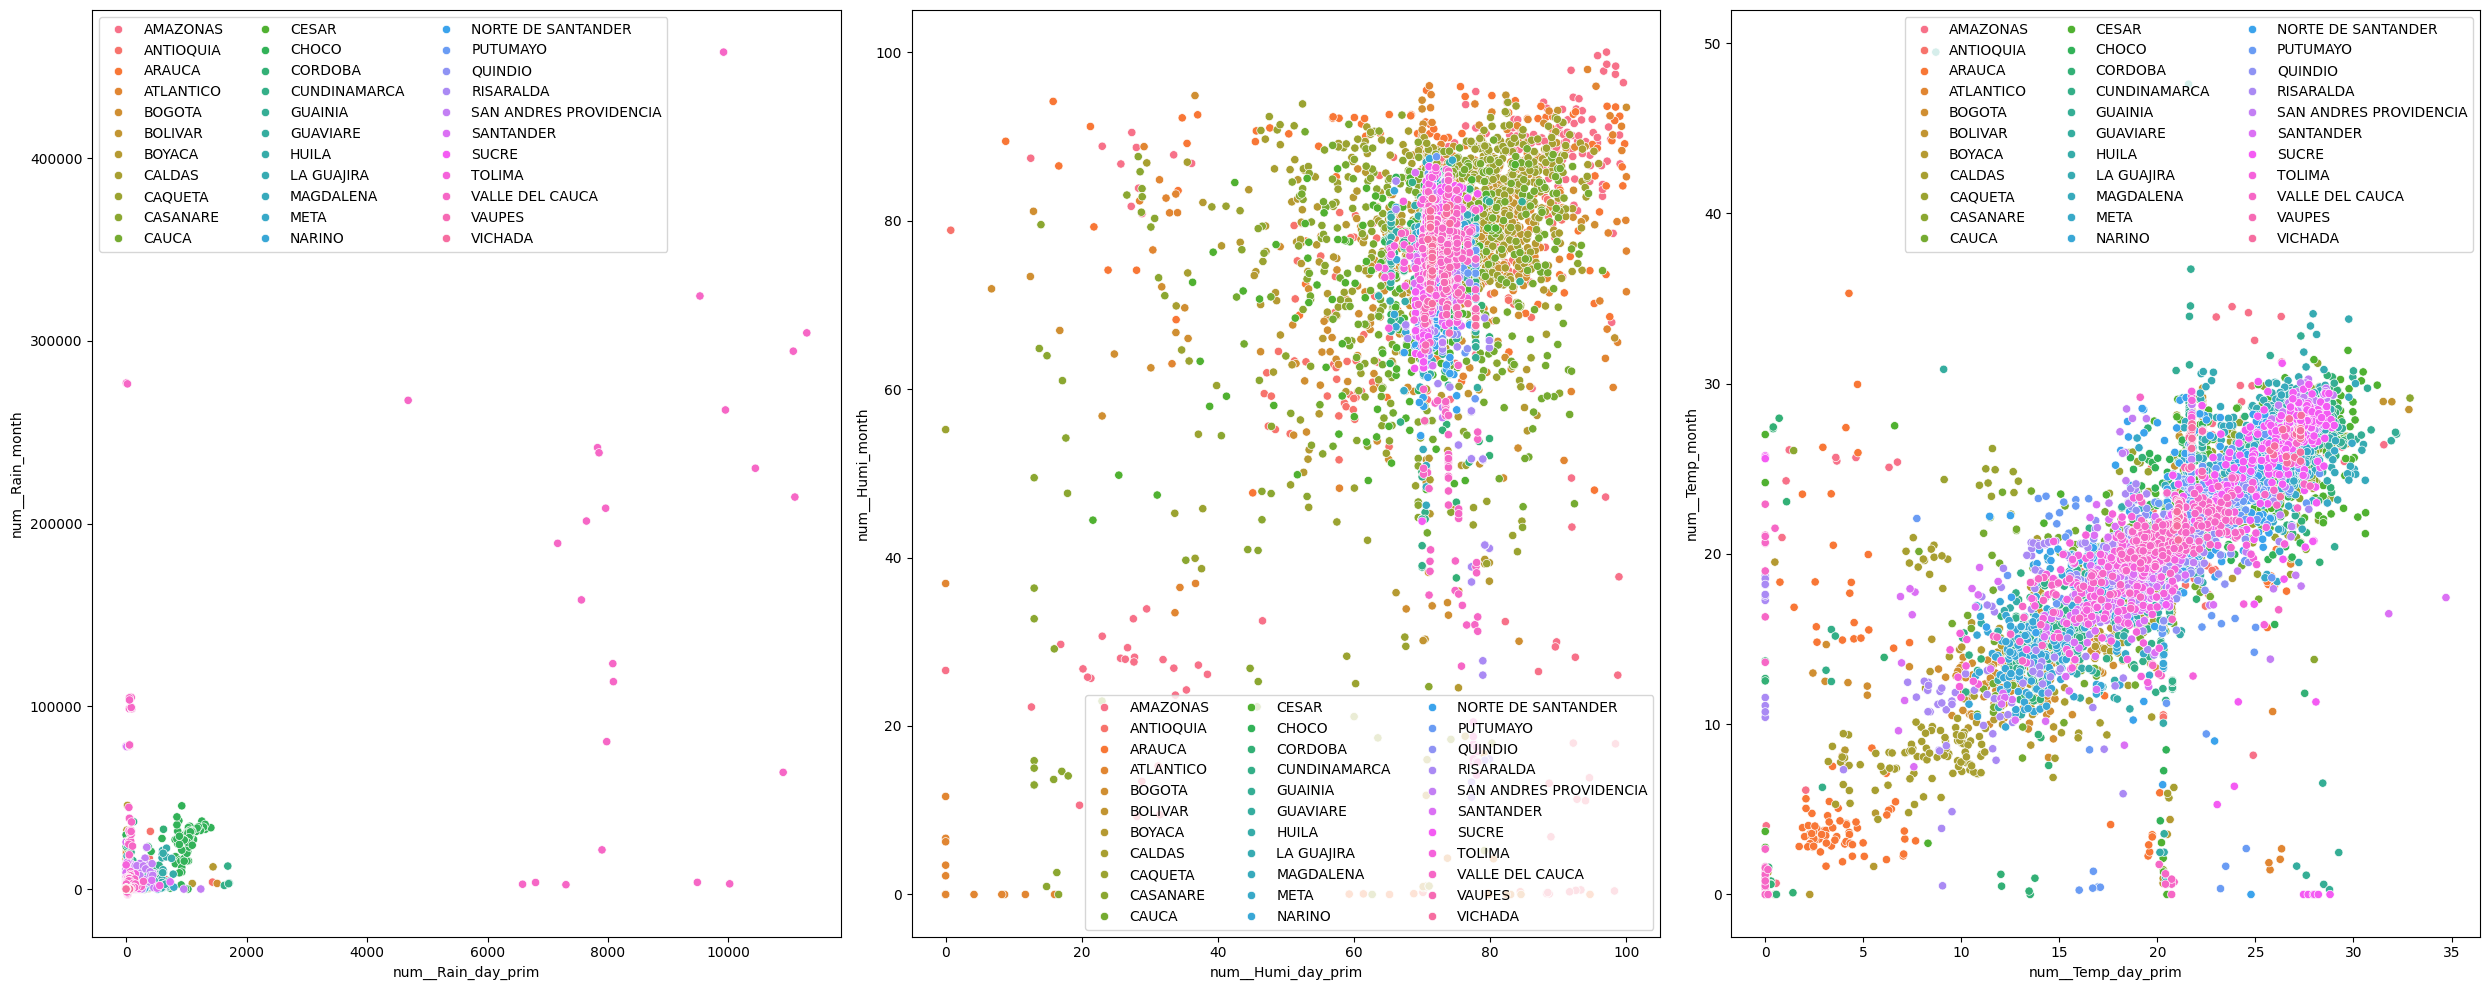

In [23]:
plt.figure(figsize=(25,10))
plt.subplot(131)
sns.scatterplot(data=df_imputed, x="num__Rain_day_prim", y="num__Rain_month",hue="Departamento");plt.legend(ncol=3)
plt.subplot(132)
sns.scatterplot(data=df_imputed, x="num__Humi_day_prim", y="num__Humi_month",hue="Departamento");plt.legend(ncol=3)
plt.subplot(133)
sns.scatterplot(data=df_imputed, x="num__Temp_day_prim", y="num__Temp_month",hue="Departamento");plt.legend(ncol=3)
plt.tight_layout();plt.show()

In [24]:
data.to_csv("DataAllMining_Original2.csv")
df_imputed.to_csv("DataAllMining_Imputed2.csv")

## Primera version....

In [26]:
depart,month_day,year,rain_day,rain_month,humi_day,humi_month,temp_day,temp_month=[],[],[],[],[],[],[],[],[]
for i in range(2006,2025,1):
    for j in range(1,13,1):
        for k in list(rain_days["Departamento"].unique()):
            a1=rain_days[(rain_days["Departamento"]==k)&(rain_days["date"].dt.year==i)&(rain_days["date"].dt.month==1)&(rain_days["date"].dt.day==j)]["sum_ValorObservado"].sum()
            a2=rain_days[(rain_days["Departamento"]==k)&(rain_days["date"].dt.year==i)&(rain_days["date"].dt.month==j)]["sum_ValorObservado"].sum()
            b1=temp_days[(temp_days["Departamento"]==k)&(temp_days["date"].dt.year==i)&(temp_days["date"].dt.month==1)&(temp_days["date"].dt.day==j)]["sum_ValorObservado"].mean()
            b2=temp_days[(temp_days["Departamento"]==k)&(temp_days["date"].dt.year==i)&(temp_days["date"].dt.month==j)]["sum_ValorObservado"].mean()
            c1=humi_days[(humi_days["Departamento"]==k)&(humi_days["date"].dt.year==i)&(humi_days["date"].dt.month==1)&(humi_days["date"].dt.day==j)]["sum_ValorObservado"].mean()
            c2=humi_days[(humi_days["Departamento"]==k)&(humi_days["date"].dt.year==i)&(humi_days["date"].dt.month==j)]["sum_ValorObservado"].mean()
            depart.append(k)
            year.append(i)
            month_day.append(j)
            rain_day.append(a1)
            rain_month.append(a2)
            temp_day.append(b1)
            temp_month.append(b2)
            humi_day.append(c1)
            humi_month.append(c2)

In [27]:
data0=pd.DataFrame({"Departamento":depart,
                  "Year":year,
                   "Month/Day":month_day,
                  "Rain_day":rain_day,
                  "Rain_month":rain_month,
                  "Temp_day":temp_day,
                  "Temp_month":temp_month,
                  "Humi_day":humi_day,
                  "Humi_month":humi_month})

In [28]:
data0

,Departamento,Year,Month/Day,Rain_day,Rain_month,Temp_day,Temp_month,Humi_day,Humi_month
0,AMAZONAS,2006,1,0.0,0.000,NaN,NaN,NaN,NaN
1,ANTIOQUIA,2006,1,0.0,199.500,19.324113,18.957285,72.29108,74.619183
2,ARAUCA,2006,1,0.0,0.000,NaN,NaN,NaN,NaN
3,ATLANTICO,2006,1,0.0,0.000,NaN,NaN,NaN,NaN
4,BOGOTA,2006,1,0.1,56.600,13.195833,13.873947,NaN,NaN
...,...,...,...,...,...,...,...,...,...
7519,SUCRE,2024,12,31.5,2549.600,28.600000,27.541524,NaN,NaN
7520,TOLIMA,2024,12,7.7,5263.420,25.547887,21.558212,NaN,NaN
7521,VALLE DEL CAUCA,2024,12,5.0,2829.232,25.485417,23.484995,NaN,NaN
7522,VAUPES,2024,12,0.0,305.400,NaN,NaN,NaN,NaN


In [29]:
data0.isna().sum()/len(data)*100

Departamento     0.000000
Year             0.000000
Month/Day        0.000000
Rain_day         0.000000
Rain_month       0.000000
Temp_day        19.570406
Temp_month      13.688053
Humi_day        74.856100
Humi_month      72.174646
dtype: float64

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

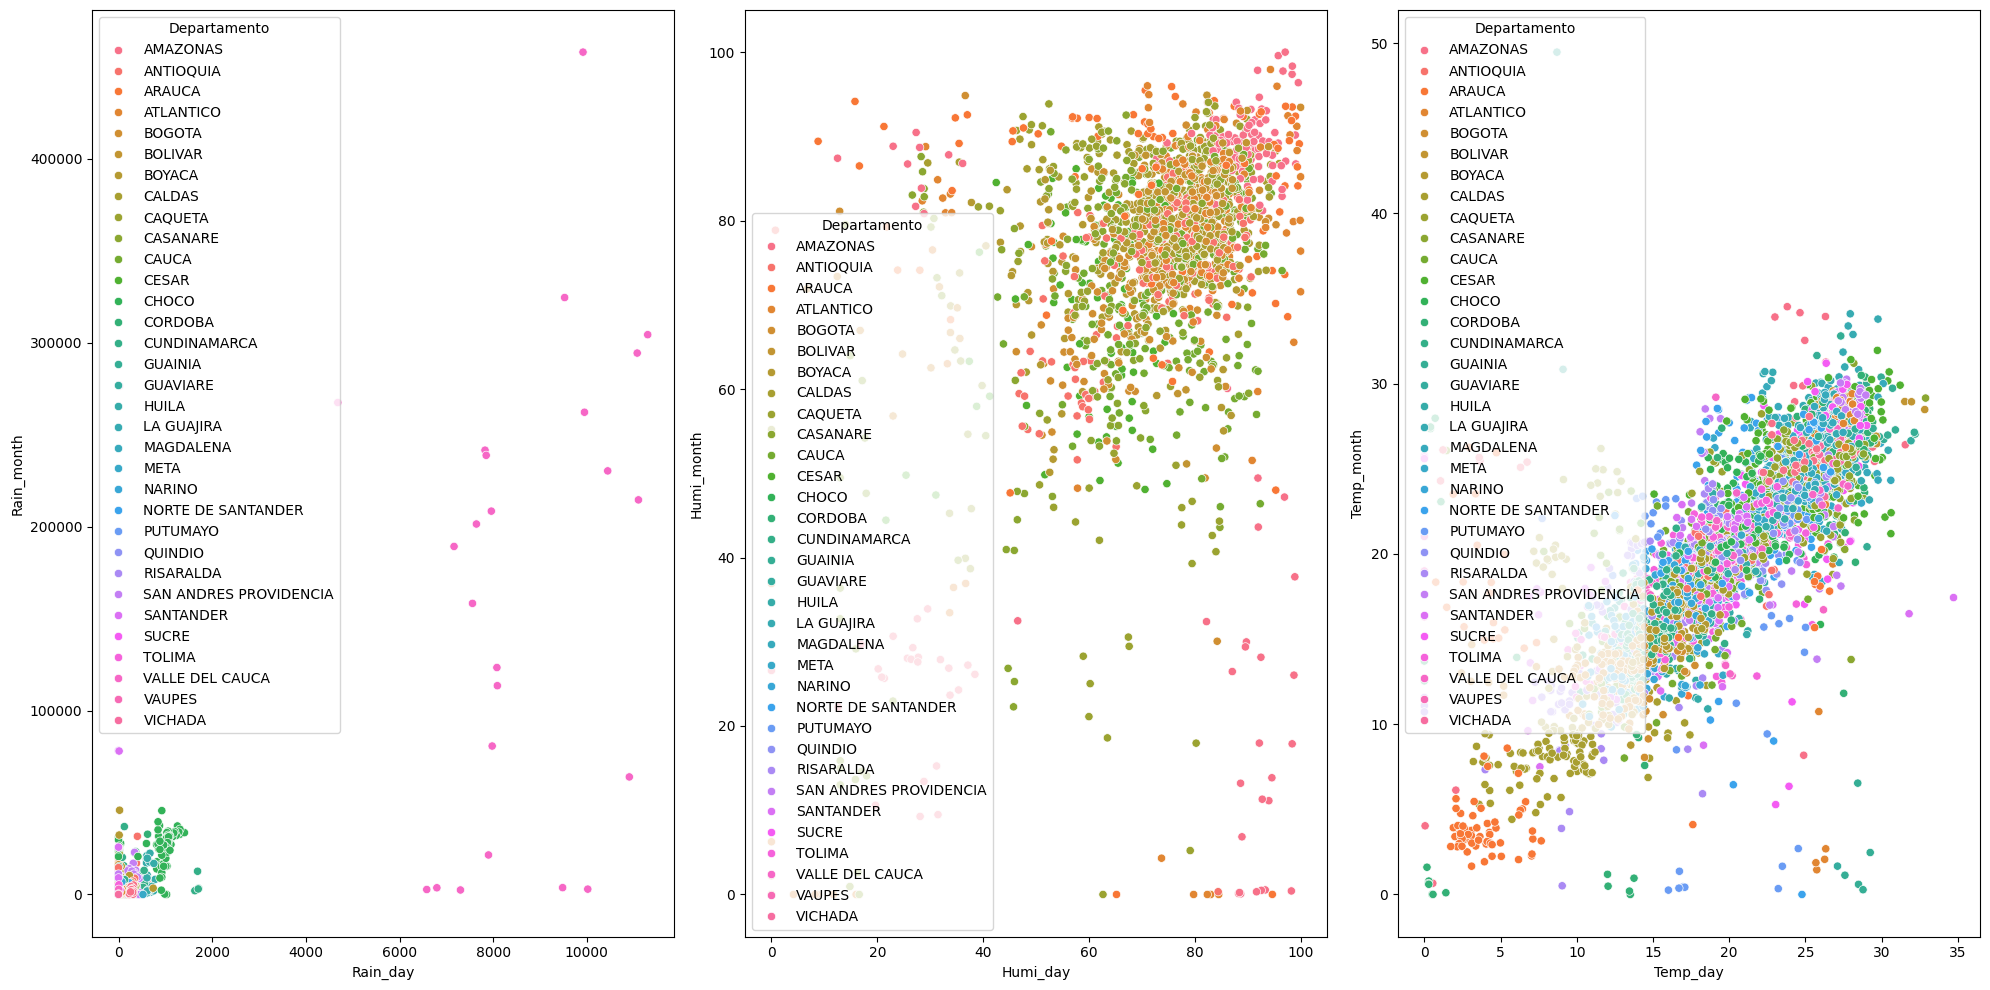

In [31]:
plt.figure(figsize=(20,10))
plt.subplot(131)
sns.scatterplot(data=data0, x="Rain_day", y="Rain_month",hue="Departamento")
plt.subplot(132)
sns.scatterplot(data=data0, x="Humi_day", y="Humi_month",hue="Departamento")
plt.subplot(133)
sns.scatterplot(data=data0, x="Temp_day", y="Temp_month",hue="Departamento")
plt.tight_layout();plt.show()

In [32]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# ————————————————
# 0) Carga tu DataFrame (ya limpio, con columnas Year, Month/Day, Rain_day…, Departamento)
# ————————————————
# Por ejemplo, si vienes de Spark:
# df = T_spark.toPandas()

# O si ya estás en pandas:
# df = tu_dataframe_pandas.copy()

# ————————————————
# 1) Define las variables
# ————————————————
cat_feats = ['Departamento']
num_feats = ['Year', 'Month/Day',
             'Rain_day', 'Rain_month',
             'Temp_day', 'Temp_month',
             'Humi_day', 'Humi_month']

# ————————————————
# 2) Preprocesador: one‑hot para depto, passthrough para numéricas
# ————————————————
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_feats),
    ('num', 'passthrough', num_feats),
])

# ————————————————
# 3) Iterative Imputer con bosque aleatorio
# ————————————————
rf_estimator = RandomForestRegressor(
    n_estimators=100,
    n_jobs=-1,
    random_state=0
)

imputer = IterativeImputer(
    estimator=rf_estimator,
    max_iter=10,               # número de rondas de imputación
    initial_strategy='mean',   # cómo rellenar al comienzo
    imputation_order='ascending',
    random_state=0
)

pipeline = Pipeline([
    ('pre', preprocessor),
    ('imp', imputer),
])

# ————————————————
# 4) Ajusta y transforma
# ————————————————
X_imputed = pipeline.fit_transform(data0)

# ————————————————
# 5) Reconstruye DataFrame con nombres de columnas
# ————————————————
# Obtén nombres de features tras el ColumnTransformer
feature_names = pipeline.named_steps['pre'].get_feature_names_out()

df_imputed0 = pd.DataFrame(X_imputed, columns=feature_names)

# Si quieres volver a unir columna 'Departamento' como categoría, podrías:
# departamento_cols = [c for c in feature_names if c.startswith('cat__Departamento')]
# df_imputed['Departamento'] = df_imputed[departamento_cols].idxmax(axis=1).str.replace('cat__Departamento_', '')

# ————————————————
# 6) Listo: df_imputed ya no tiene NaNs
# ————————————————
print(df_imputed.info())
print(df_imputed.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7123 entries, 0 to 7122
Data columns (total 50 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   cat__Departamento_AMAZONAS                7123 non-null   float64
 1   cat__Departamento_ANTIOQUIA               7123 non-null   float64
 2   cat__Departamento_ARAUCA                  7123 non-null   float64
 3   cat__Departamento_ATLANTICO               7123 non-null   float64
 4   cat__Departamento_BOGOTA                  7123 non-null   float64
 5   cat__Departamento_BOLIVAR                 7123 non-null   float64
 6   cat__Departamento_BOYACA                  7123 non-null   float64
 7   cat__Departamento_CALDAS                  7123 non-null   float64
 8   cat__Departamento_CAQUETA                 7123 non-null   float64
 9   cat__Departamento_CASANARE                7123 non-null   float64
 10  cat__Departamento_CAUCA             

In [33]:
df_imputed0

,cat__Departamento_AMAZONAS,cat__Departamento_ANTIOQUIA,cat__Departamento_ARAUCA,cat__Departamento_ATLANTICO,cat__Departamento_BOGOTA,cat__Departamento_BOLIVAR,cat__Departamento_BOYACA,cat__Departamento_CALDAS,cat__Departamento_CAQUETA,cat__Departamento_CASANARE,...,cat__Departamento_VAUPES,cat__Departamento_VICHADA,num__Year,num__Month/Day,num__Rain_day,num__Rain_month,num__Temp_day,num__Temp_month,num__Humi_day,num__Humi_month
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2006.0,1.0,0.0,0.000,25.017378,23.900927,88.102616,81.407159
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2006.0,1.0,0.0,199.500,19.324113,18.957285,72.291080,74.619183
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2006.0,1.0,0.0,0.000,4.905264,3.951957,78.035940,74.718325
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2006.0,1.0,0.0,0.000,25.899578,25.022157,77.344941,74.797651
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2006.0,1.0,0.1,56.600,13.195833,13.873947,72.581196,73.826251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7519,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2024.0,12.0,31.5,2549.600,28.600000,27.541524,78.865939,83.827022
7520,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2024.0,12.0,7.7,5263.420,25.547887,21.558212,65.350509,78.336104
7521,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2024.0,12.0,5.0,2829.232,25.485417,23.484995,71.907145,79.920617
7522,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,2024.0,12.0,0.0,305.400,27.176081,25.577988,82.720172,81.038751


In [34]:
df_imputed0["Departamento"]=data["Departamento"]

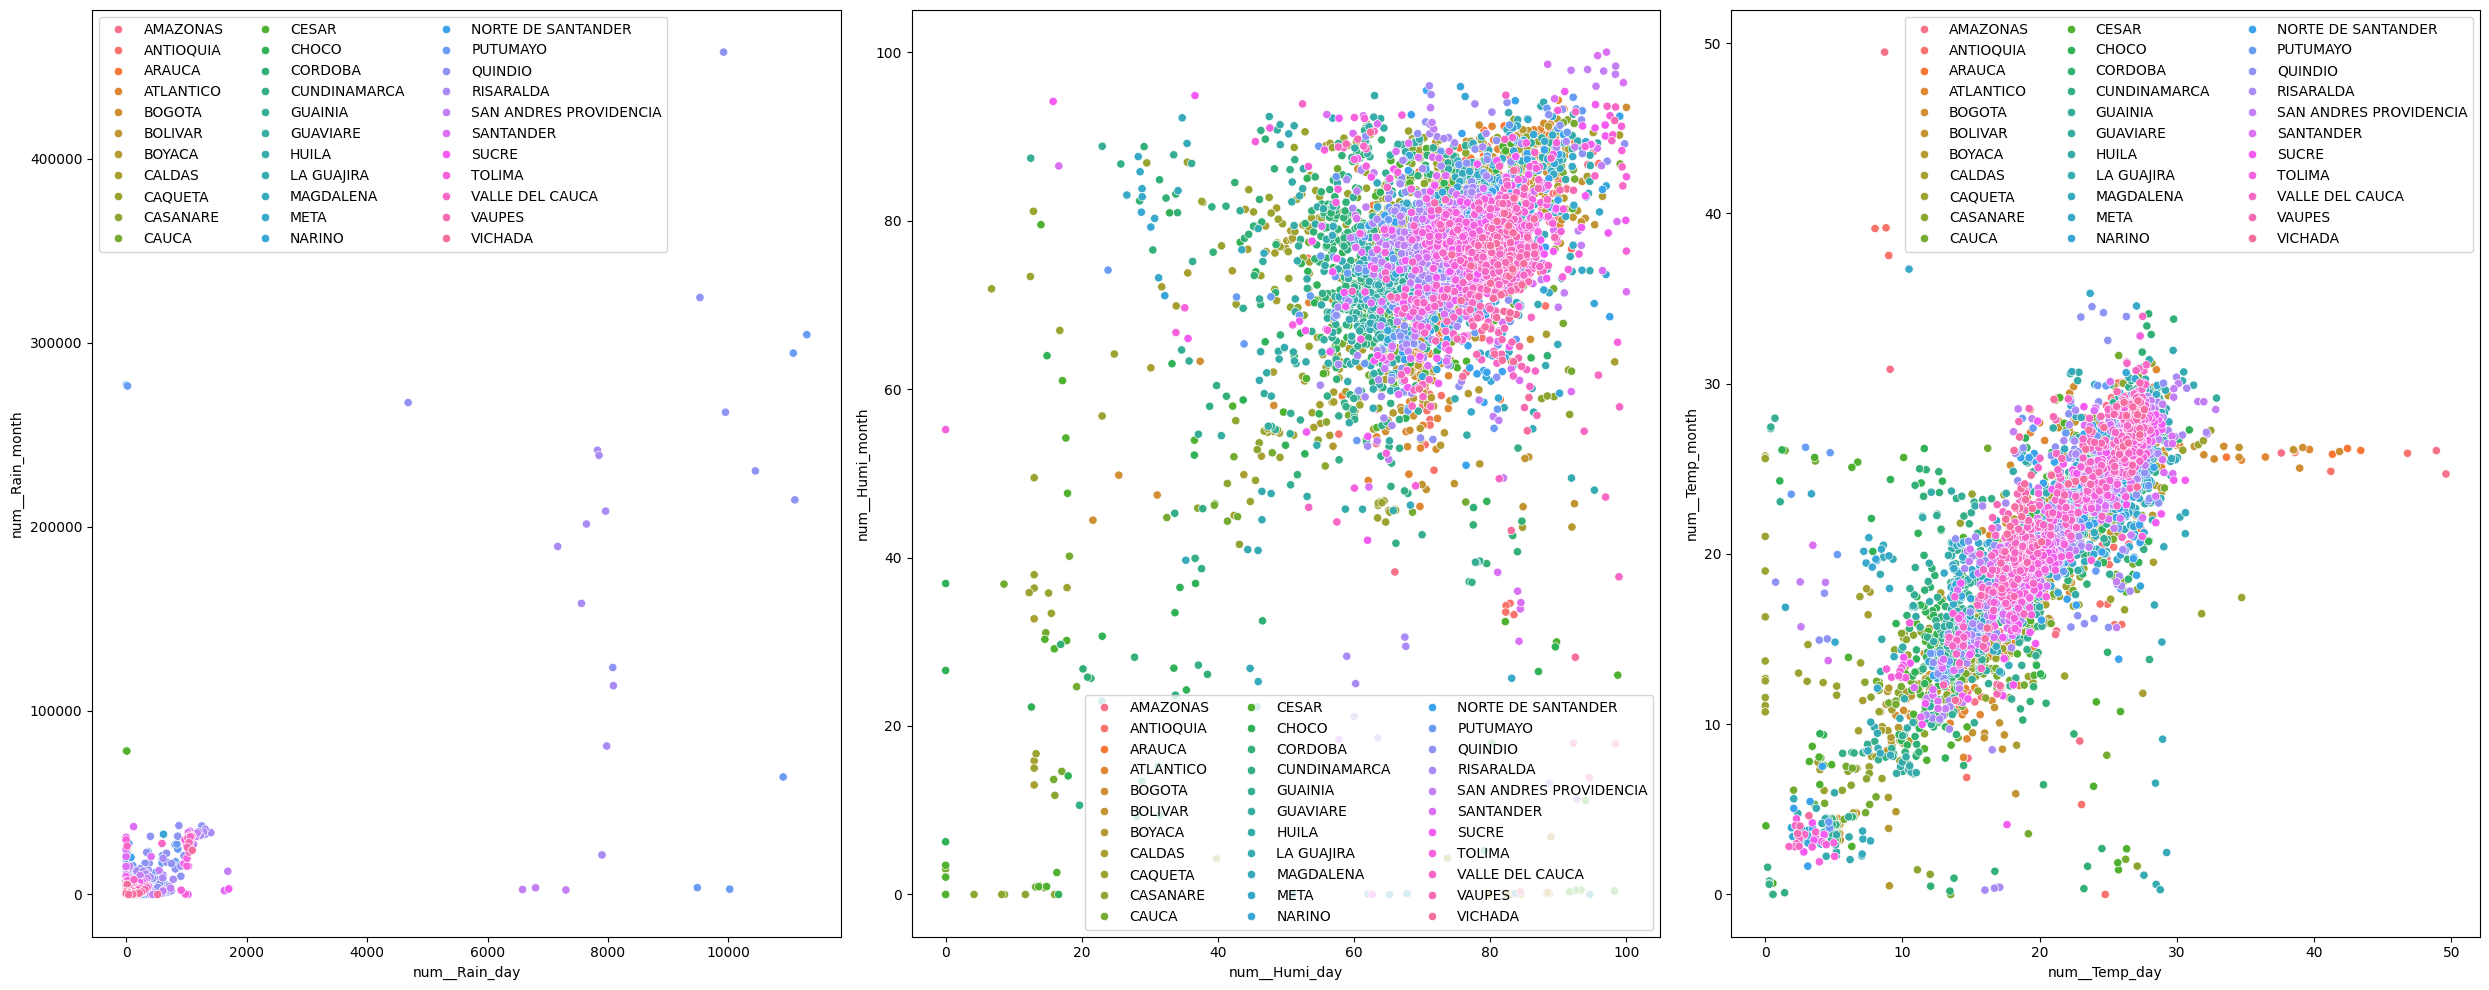

In [37]:
plt.figure(figsize=(25,10))
plt.subplot(131)
sns.scatterplot(data=df_imputed0, x="num__Rain_day", y="num__Rain_month",hue="Departamento");plt.legend(ncol=3)
plt.subplot(132)
sns.scatterplot(data=df_imputed0, x="num__Humi_day", y="num__Humi_month",hue="Departamento");plt.legend(ncol=3)
plt.subplot(133)
sns.scatterplot(data=df_imputed0, x="num__Temp_day", y="num__Temp_month",hue="Departamento");plt.legend(ncol=3)
plt.tight_layout();plt.show()

In [38]:
data0.to_csv("DataAllMining_Original.csv")
df_imputed0.to_csv("DataAllMining_Imputed.csv")